# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [5]:
import numpy as np
from matplotlib import pyplot as plt
from functools import partial
from scipy.optimize import fmin
import torch
import os, glob
from pathlib import Path

from indentation.indentationset import IndentationSet
from indentation.processing.find_contact import findContact_minimum, findContact_blackMagic, findContact_blackMagic_CNN
from indentation.processing.signal import do_nothing, crop_start
from indentation.processing.calculate_parameters import parameter_youngs_modulus
from indentation.processing.plotting import plot_curve_parameters_bar, plot_instance_parameters_bar, plot_mean_force_curves
from indentation.ml.models import ConvClassifier_1, ConvClassifier_2

In [13]:
basepath   = os.path.join(Path.home(), r"Dropbox/aaa_current_projects/mitchell_mouse_pancreas")
model_path = os.path.join(Path.home(), r"Dropbox/aaa_current_projects/mitchell_mouse_pancreas/software/torch_model3")

paths_m8  = glob.glob(os.path.join(basepath, r"data/091024/m8*array3.dat")) # exp
paths_m6  = glob.glob(os.path.join(basepath, r"data/130924/m6*.dat")) # exp
paths_m4  = glob.glob(os.path.join(basepath, r"data/290824/m4*.dat")) # exp
paths_m5  = glob.glob(os.path.join(basepath, r"data/130924/m5*.dat")) # ctrl
paths_m3  = glob.glob(os.path.join(basepath, r"data/290824/m3*.dat")) # ctrl
paths_m11 = glob.glob(os.path.join(basepath, r"data/221024/m11*.dat")) # ctrl

paths_ctr = [paths_m5, paths_m3, paths_m11]
paths_exp = [paths_m8, paths_m6, paths_m4]

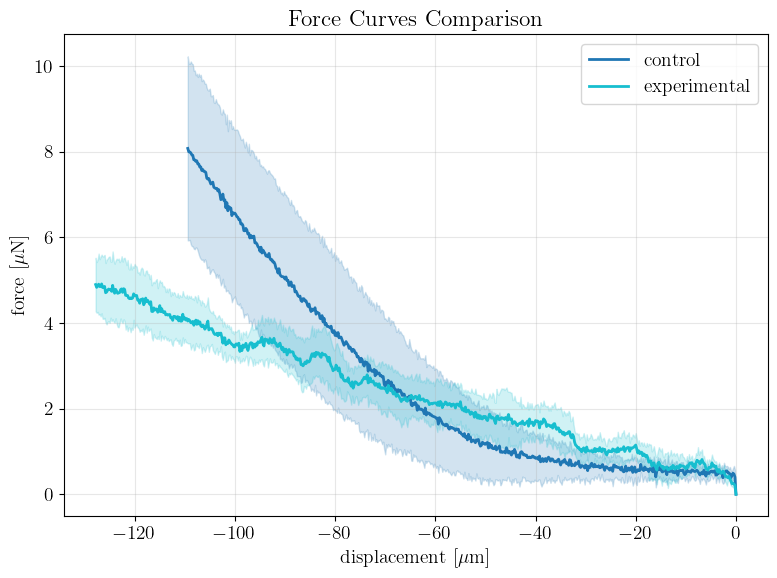

13 9


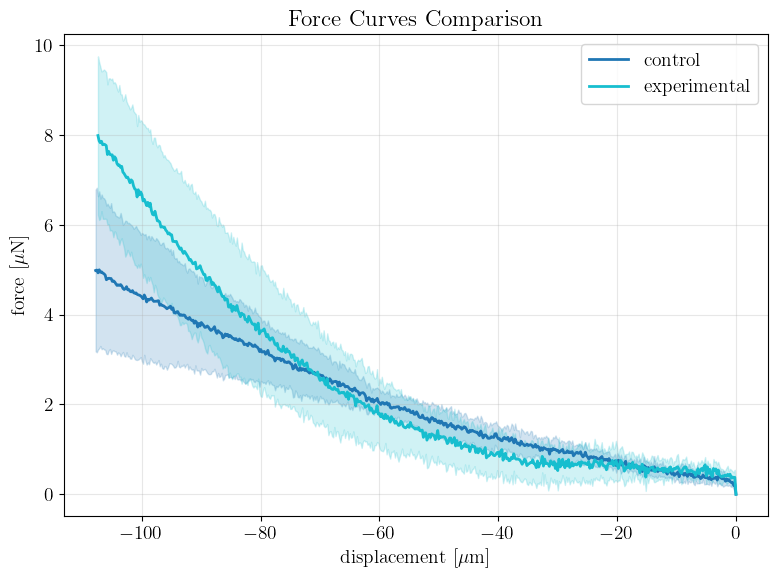

27 9


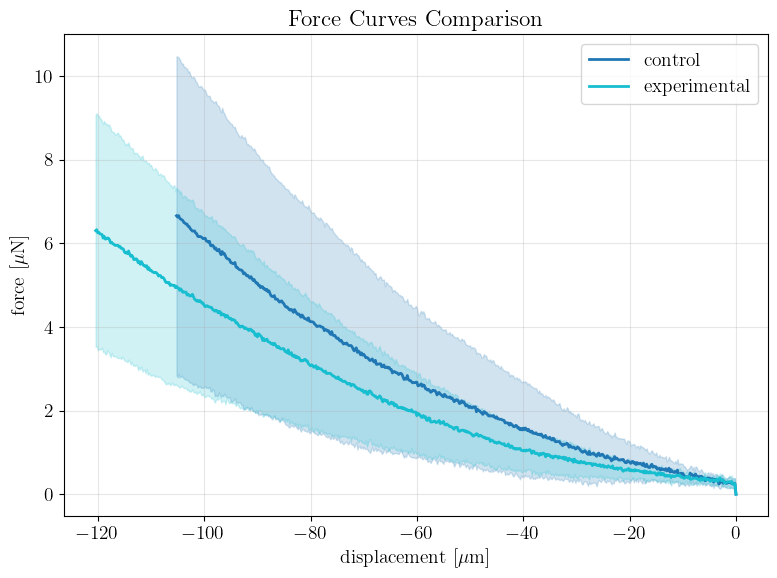

18 27


In [17]:
mice_ctr = [IndentationSet(paths, exp_type="ft") for paths in paths_ctr]
mice_exp = [IndentationSet(paths, exp_type="ft") for paths in paths_exp]

processing_pl = [partial(crop_start, ix_start=5), findContact_minimum]

for i in range(3):
    mice_ctr[i].process_raw(processing_pl)
    mice_exp[i].process_raw(processing_pl)
    
    mice_ctr[i].calculate_mean()
    mice_exp[i].calculate_mean()

    plot_mean_force_curves(mice_ctr[i], mice_exp[i], labels=["control", "experimental"])
    print(len(mice_ctr[i]), len(mice_exp[i]))

Mean and std: 166.1798100122889 7.981232178748406
Mean and std: 111.40306599947621 1.4716858686409848


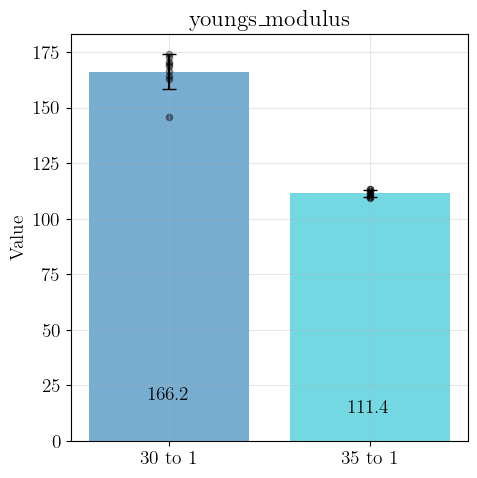

In [17]:
function_arguments = dict(radius=100, nu=0.5, cutoff=10, keyname="youngs_modulus")
p30.calculate_curve_parameter(function=parameter_youngs_modulus, **function_arguments)
p35.calculate_curve_parameter(function=parameter_youngs_modulus, **function_arguments)
plot_curve_parameters_bar(p30, p35, 
                          parameter_names=['youngs_modulus'],
                          labels=['30 to 1', '35 to 1'],
                          figsize=(5,5))